In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# 1. Rutas y carga de datos y modelos
export_path = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Models/'
data_path = (
    '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/train_topicos.csv'
)

df = pd.read_csv(data_path)
df['text_avanzado'] = df['text_avanzado'].fillna('')

tfidf = joblib.load(export_path + 'tfidf_vectorizer.joblib')
lr_model = joblib.load(export_path + 'lr_model.joblib')
nb_model = joblib.load(export_path + 'nb_model.joblib')

# 2. Recrear el Split exacto
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['target']
)

# Vectorizar conjuntos
X_train_vec = tfidf.transform(df_train['text_avanzado'])
X_test_vec = tfidf.transform(df_test['text_avanzado'])


# 3. Función de umbral
def get_predictions_with_threshold(model, X_data, threshold=0.6):
  probs = model.predict_proba(X_data)
  max_probs = probs.max(axis=1)
  predictions = model.predict(X_data)
  return np.where(max_probs < threshold, 2, predictions)


# 4. Generar predicciones para RL y Naive Bayes
threshold = 0.6
modelos = {'Regresión Logística': lr_model, 'Naive Bayes': nb_model}

preds_ml = {}
for name, model in modelos.items():
  preds_ml[name] = {
      'train': get_predictions_with_threshold(model, X_train_vec, threshold),
      'test': get_predictions_with_threshold(model, X_test_vec, threshold),
  }


In [10]:
from textblob import TextBlob

def classify_sentiment_textblob(text):
  analysis = TextBlob(text)
  if analysis.sentiment.polarity < -0.1:
    return 0
  elif analysis.sentiment.polarity > 0.1:
    return 4
  else:
    return 2
#COMO EL TEXTBLOB OPERA ARROJANDO UN VALOR DE POLARIDAD YA SEA
#-1.0 o 1.0 (EXTEMADAMENTE NEGATIVO O POSITIVO)
#SE APLICA UNA CONDICIÓN EL LA LOGICA PARA IDENTIFICAR LOS NEUTROS
#(Entre -0.1 y 0.1 : Neutral (2))
#YA QUE EN EL DATASET DE TEST NO EXISTE ESA VARIABLE

preds_tb_train = df_train['text_avanzado'].apply(classify_sentiment_textblob)
preds_tb_test = df_test['text_avanzado'].apply(classify_sentiment_textblob)

In [11]:
from sklearn.metrics import classification_report

# 1. Imprimir reportes de Regresión Logística y Naive Bayes
for name, preds in preds_ml.items():
  print(f"\n{'='*15} REPORTE TRAIN: {name} {'='*15}")
  print(classification_report(df_train['target'], preds['train']))

  print(f"\n{'='*15} REPORTE TEST: {name} {'='*15}")
  print(classification_report(df_test['target'], preds['test']))

# 2. Imprimir reportes de TextBlob
print(f"\n{'='*15} REPORTE TRAIN: TextBlob (Baseline) {'='*15}")
print(classification_report(df_train['target'], preds_tb_train))

print(f"\n{'='*15} REPORTE TEST: TextBlob (Baseline) {'='*15}")
print(classification_report(df_test['target'], preds_tb_test))


=============== REPORTE TRAIN: Regresión Logística ===============


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.91      0.75      0.82    640000
           2       0.00      0.00      0.00         0
           4       0.91      0.80      0.85    640000

    accuracy                           0.77   1280000
   macro avg       0.61      0.51      0.56   1280000
weighted avg       0.91      0.77      0.83   1280000


=============== REPORTE TEST: Regresión Logística ===============
              precision    recall  f1-score   support

           0       0.84      0.72      0.77    160000
           2       0.00      0.00      0.00         0
           4       0.84      0.73      0.78    160000

    accuracy                           0.72    320000
   macro avg       0.56      0.48      0.52    320000
weighted avg       0.84      0.72      0.77    320000


=============== REPORTE TRAIN: Naive Bayes ===============


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

              precision    recall  f1-score   support

           0       0.94      0.83      0.88    640000
           2       0.00      0.00      0.00         0
           4       0.96      0.78      0.86    640000

    accuracy                           0.81   1280000
   macro avg       0.63      0.54      0.58   1280000
weighted avg       0.95      0.81      0.87   1280000


=============== REPORTE TEST: Naive Bayes ===============
              precision    recall  f1-score   support

           0       0.84      0.68      0.75    160000
           2       0.00      0.00      0.00         0
           4       0.86      0.61      0.71    160000

    accuracy                           0.64    320000
   macro avg       0.57      0.43      0.49    320000
weighted avg       0.85      0.64      0.73    320000


=============== REPORTE TRAIN: TextBlob (Baseline) ===============


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.77      0.25      0.38    640000
           2       0.00      0.00      0.00         0
           4       0.66      0.50      0.57    640000

    accuracy                           0.37   1280000
   macro avg       0.48      0.25      0.32   1280000
weighted avg       0.71      0.37      0.47   1280000


=============== REPORTE TEST: TextBlob (Baseline) ===============
              precision    recall  f1-score   support

           0       0.77      0.25      0.38    160000
           2       0.00      0.00      0.00         0
           4       0.66      0.50      0.57    160000

    accuracy                           0.38    320000
   macro avg       0.48      0.25      0.32    320000
weighted avg       0.71      0.38      0.47    320000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

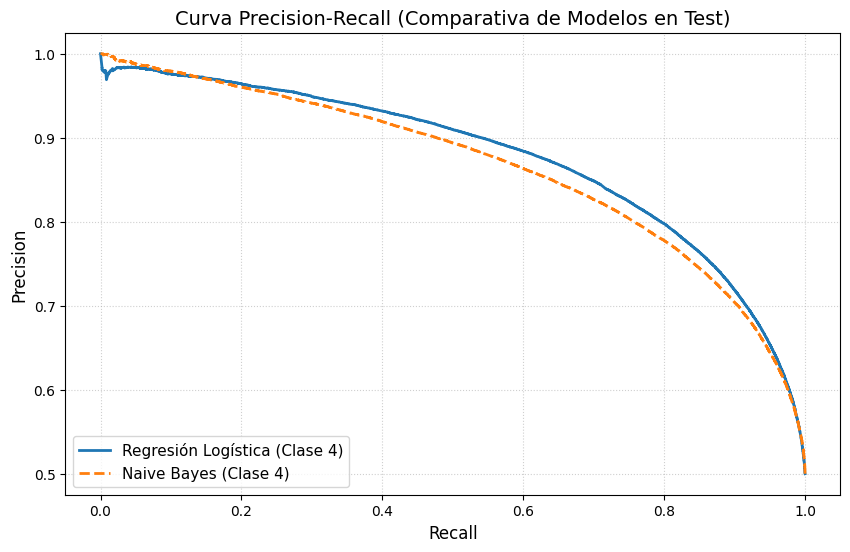

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Diccionario con las probabilidades (o scores de decisión) para el conjunto de Test
# Nota: Usamos predict_proba de los modelos entrenados en X_test_vec
probas_lr = lr_model.predict_proba(X_test_vec)
probas_nb = nb_model.predict_proba(X_test_vec)

plt.figure(figsize=(10, 6))

# Como trabajamos con multiclase (0, 2, 4), evaluamos para la clase positiva (clase 4)
precision_lr, recall_lr, _ = precision_recall_curve(
    (df_test['target'] == 4).astype(int), probas_lr[:, 1]
)
precision_nb, recall_nb, _ = precision_recall_curve(
    (df_test['target'] == 4).astype(int), probas_nb[:, 1]
)

plt.plot(recall_lr, precision_lr, label='Regresión Logística (Clase 4)', lw=2)
plt.plot(
    recall_nb, precision_nb, label='Naive Bayes (Clase 4)', lw=2, linestyle='--'
)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(
    'Curva Precision-Recall (Comparativa de Modelos en Test)', fontsize=14
)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Regresión logistica se mantiene mas preciso respecto al recall en comparación con bayes.

#Al aplicar el threshold, ambos modelos predicen el tercer outcome, los tweet neutros, por incertidumbre en la predicción, pero como en el dataset de train no se encuentra esa variable el soporte queda en 0

# Como conclución final, se encuentra que el textblob obtuvo un accuracy muy inferior a comparación a los mmodelos entrenados, lo cual se asume que es debido a la propia naturaleza del modelo al ser pre-entrenado con un diccionario y reglas ya cargados.
#Como tambien, bayes tiene mas tendencia al overfitting que la regresión linear al pasar de 81% en test a 64% en test, mientras que rl se mantenia con 77% en train y 72% en test.